# Pop III Profile Explorer

Interactive exploration of all MESA simulation columns for each mass.  
Useful for diagnosing kinks, rate changes, and structural transitions during H-burning.

**Profile columns:** `star_age`, `log_Teff`, `log_L`, `center_h1`, `center_he4`, `he_core_mass`, `co_core_mass`, `radius`

**τ_H definition:** τ_H = (t − t_ZAMS) / (t_TAMS − t_ZAMS),  
where ZAMS = first point with center_h1 < 0.759, TAMS = first point with center_h1 < 0.001

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

In [61]:
# ── Config ─────────────────────────────────────────────────────────────────────

PROFILE_DIR = Path('profile_csv')   # relative to this notebook
ZAMS_H1 = 0.759
TAMS_H1 = 0.001

ALL_MASSES = [200, 250, 300, 400, 500, 600, 700, 800, 900, 1000,
              1, 3, 10, 15, 20, 30, 50, 87, 100, 150]

def load_profile(mass):
    """Load CSV for a given mass (int or float). Returns DataFrame or None."""
    for suffix in [f'{float(mass)}', f'{int(mass)}.0']:
        p = PROFILE_DIR / f'profile_{suffix}.csv'
        if p.exists():
            return pd.read_csv(p)
    return None

def compute_tau(df):
    """Add tau_H column. Returns (df_with_tau, iz, it, tams_reached)."""
    df = df.copy()
    cands = df[df['center_h1'] < ZAMS_H1]
    if len(cands) == 0:
        raise ValueError('ZAMS not found')
    iz = cands.index[0]
    tams = df[df['center_h1'] < TAMS_H1]
    tams_reached = len(tams) > 0
    it = tams.index[0] if tams_reached else df.index[-1]
    t = df['star_age'].values
    tH = t[it] - t[iz]
    df['tau_H'] = (t - t[iz]) / tH
    df['log_R'] = np.log10(df['radius'])
    df['dt_Myr'] = np.concatenate([[np.nan], np.diff(t)])
    # Rate of change per unit tau
    dtau = np.concatenate([[np.nan], np.diff(df['tau_H'].values)])
    for col in ['log_L', 'log_Teff', 'log_R', 'center_h1']:
        dcol = np.concatenate([[np.nan], np.diff(df[col].values)])
        df[f'd{col}_dtau'] = dcol / np.where(dtau == 0, np.nan, dtau)
    ms = df[(df['tau_H'] >= 0) & (df['tau_H'] <= 1.0)].copy()
    return ms, iz, it, tams_reached

print('Functions defined. Available masses to load:')
available = [m for m in ALL_MASSES if load_profile(m) is not None]
print(sorted(available))

Functions defined. Available masses to load:
[1, 3, 10, 15, 20, 30, 50, 87, 100, 150, 200, 250, 300, 400, 500, 600, 700, 800, 900, 1000]


---
## 1. Full parameter overview — single mass

Plots all 8 raw columns + derived log_R vs τ_H.  
**Change `MASS` below to inspect any star.**

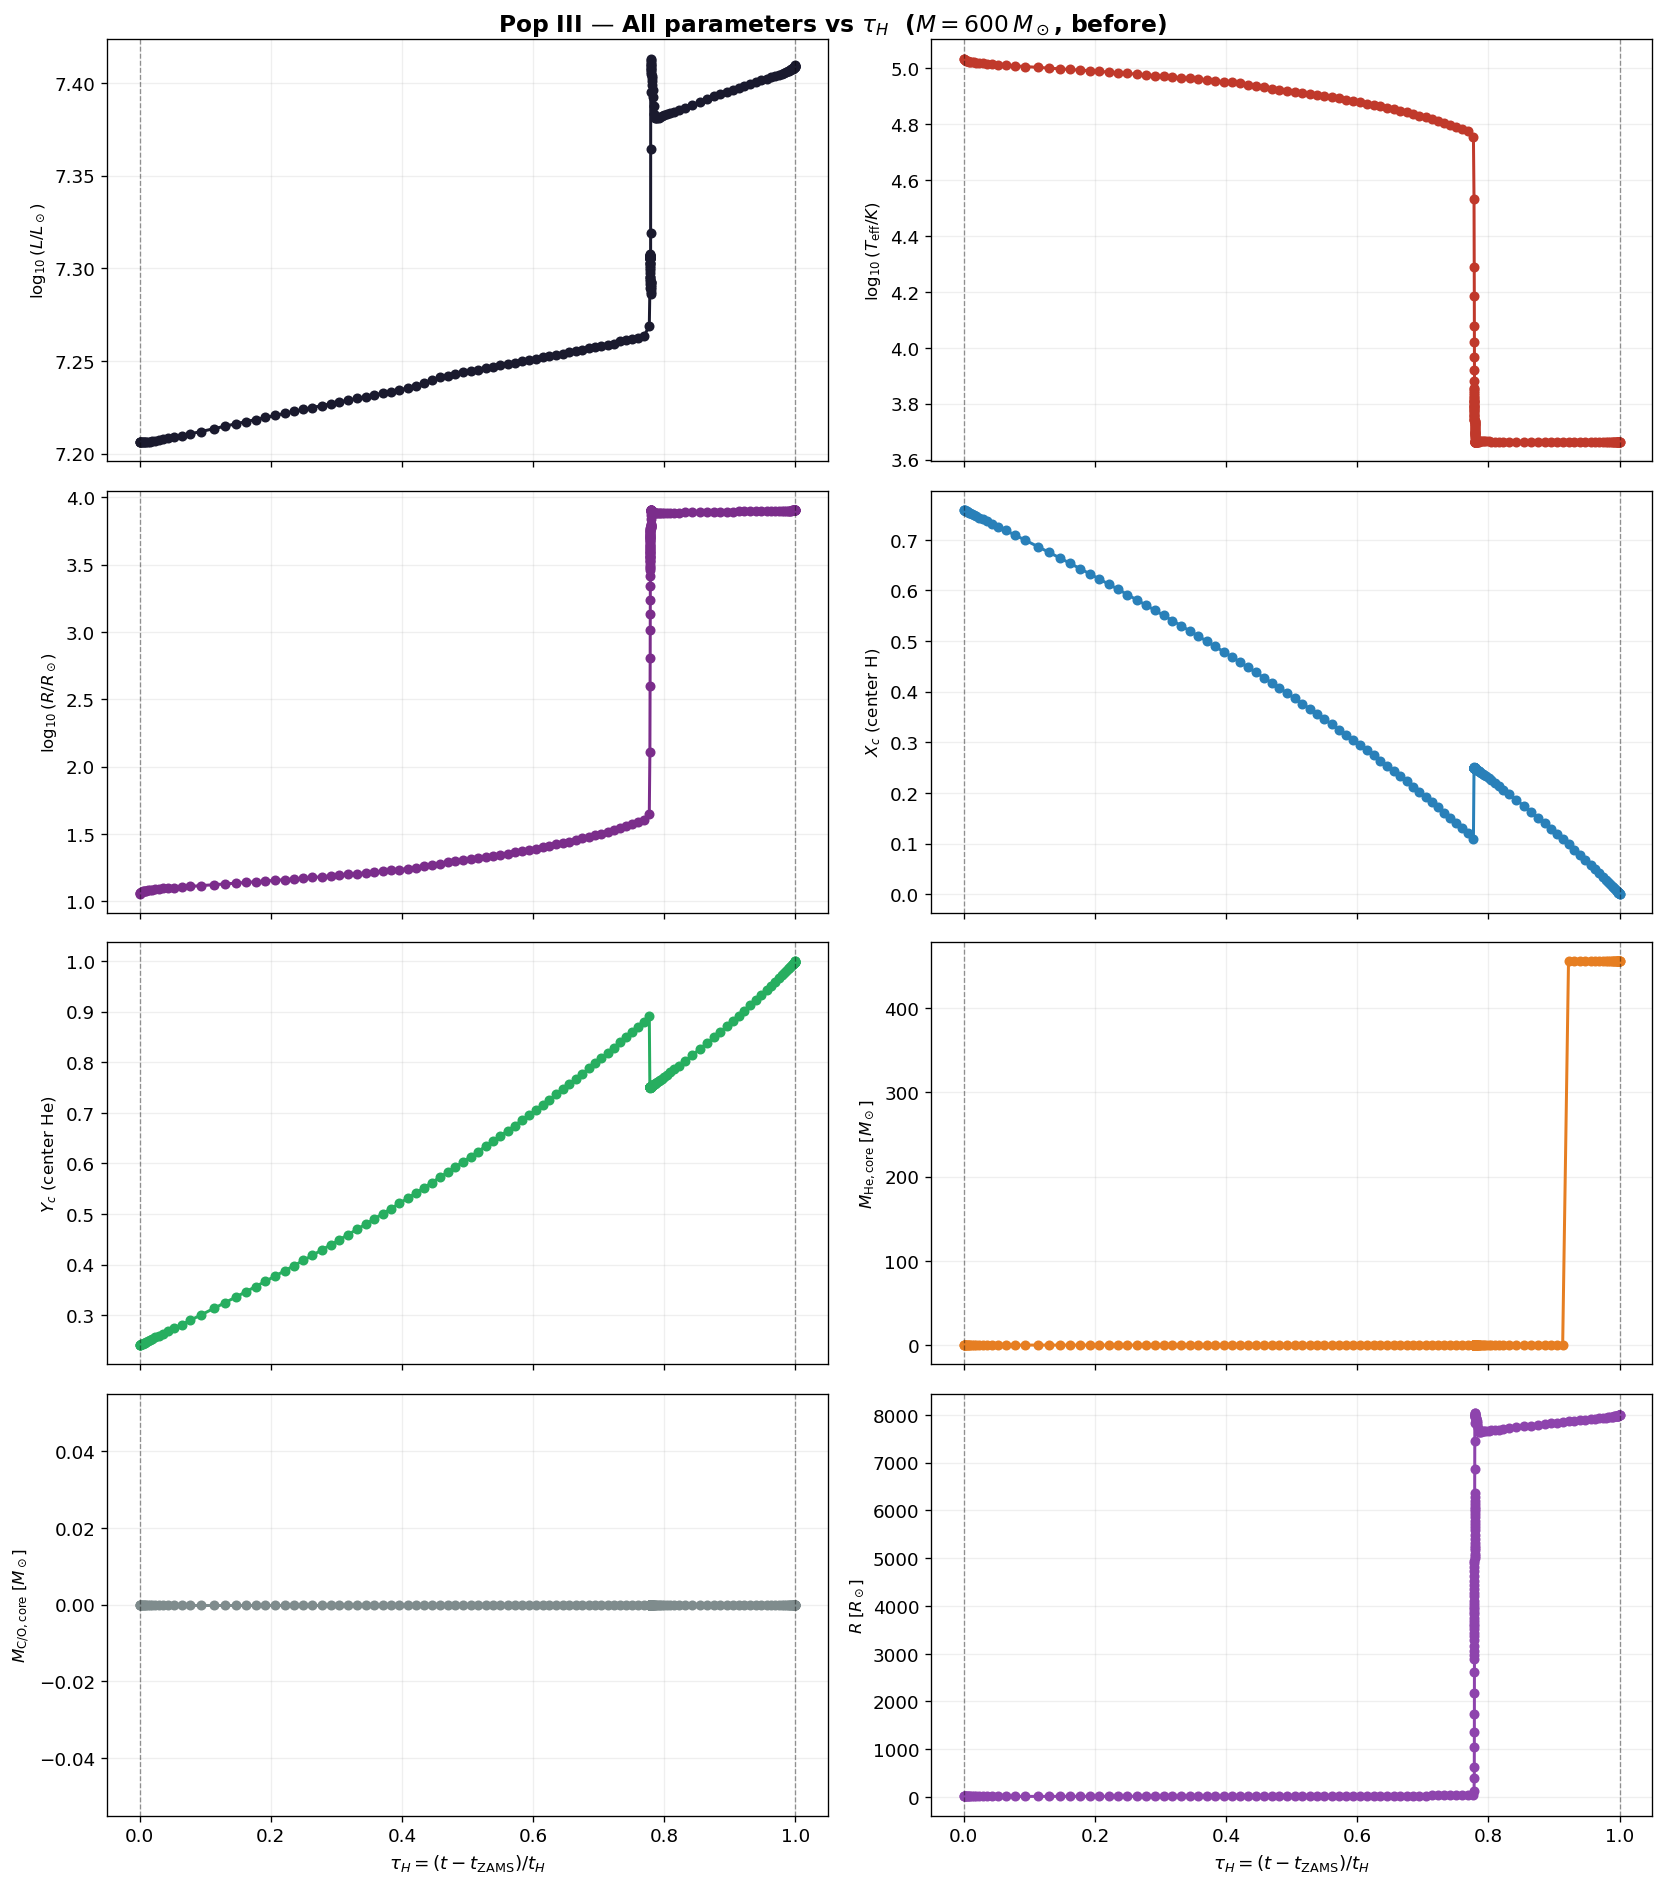


Lifetime t_H = 2.098 Myr
N timesteps on MS: 205


In [62]:
MASS = 600   # ← change this

df_raw = load_profile(MASS)
ms, iz, it, tams_ok = compute_tau(df_raw)

params = [
    ('log_L',        r'$\log_{10}(L/L_\odot)$',    '#1a1a2e'),
    ('log_Teff',     r'$\log_{10}(T_{\rm eff}/K)$', '#c0392b'),
    ('log_R',        r'$\log_{10}(R/R_\odot)$',     '#7b2d8b'),
    ('center_h1',    r'$X_c$ (center H)',            '#2980b9'),
    ('center_he4',   r'$Y_c$ (center He)',           '#27ae60'),
    ('he_core_mass', r'$M_{\rm He,core}\;[M_\odot]$','#e67e22'),
    ('co_core_mass', r'$M_{\rm C/O,core}\;[M_\odot]$','#7f8c8d'),
    ('radius',       r'$R\;[R_\odot]$',              '#8e44ad'),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True)
fig.suptitle(f'Pop III — All parameters vs $\\tau_H$  ($M={MASS}\\,M_\\odot$, before)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

tau = ms['tau_H'].values
for ax, (col, ylabel, color) in zip(axes, params):
    ax.plot(tau, ms[col].values, 'o-', color=color, lw=1.8, ms=5)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(True, alpha=0.2)
    # Mark ZAMS and TAMS
    ax.axvline(0.0, color='k', lw=0.8, ls='--', alpha=0.4)
    ax.axvline(1.0, color='k', lw=0.8, ls='--', alpha=0.4)
    if not tams_ok:
        ax.set_facecolor('#fff8e7')

for ax in axes[-2:]:
    ax.set_xlabel(r'$\tau_H = (t - t_{\rm ZAMS}) / t_H$', fontsize=11)

plt.tight_layout()
plt.show()

print(f'\nLifetime t_H = {(df_raw["star_age"][it] - df_raw["star_age"][iz])/1e6:.3f} Myr')
print(f'N timesteps on MS: {len(ms)}')

### 1b. All parameters vs full stellar time

Same 8 parameters as above, plotted over the **complete** evolution (pre-MS through post-TAMS).  
Dashed lines mark **ZAMS** and **TAMS**.

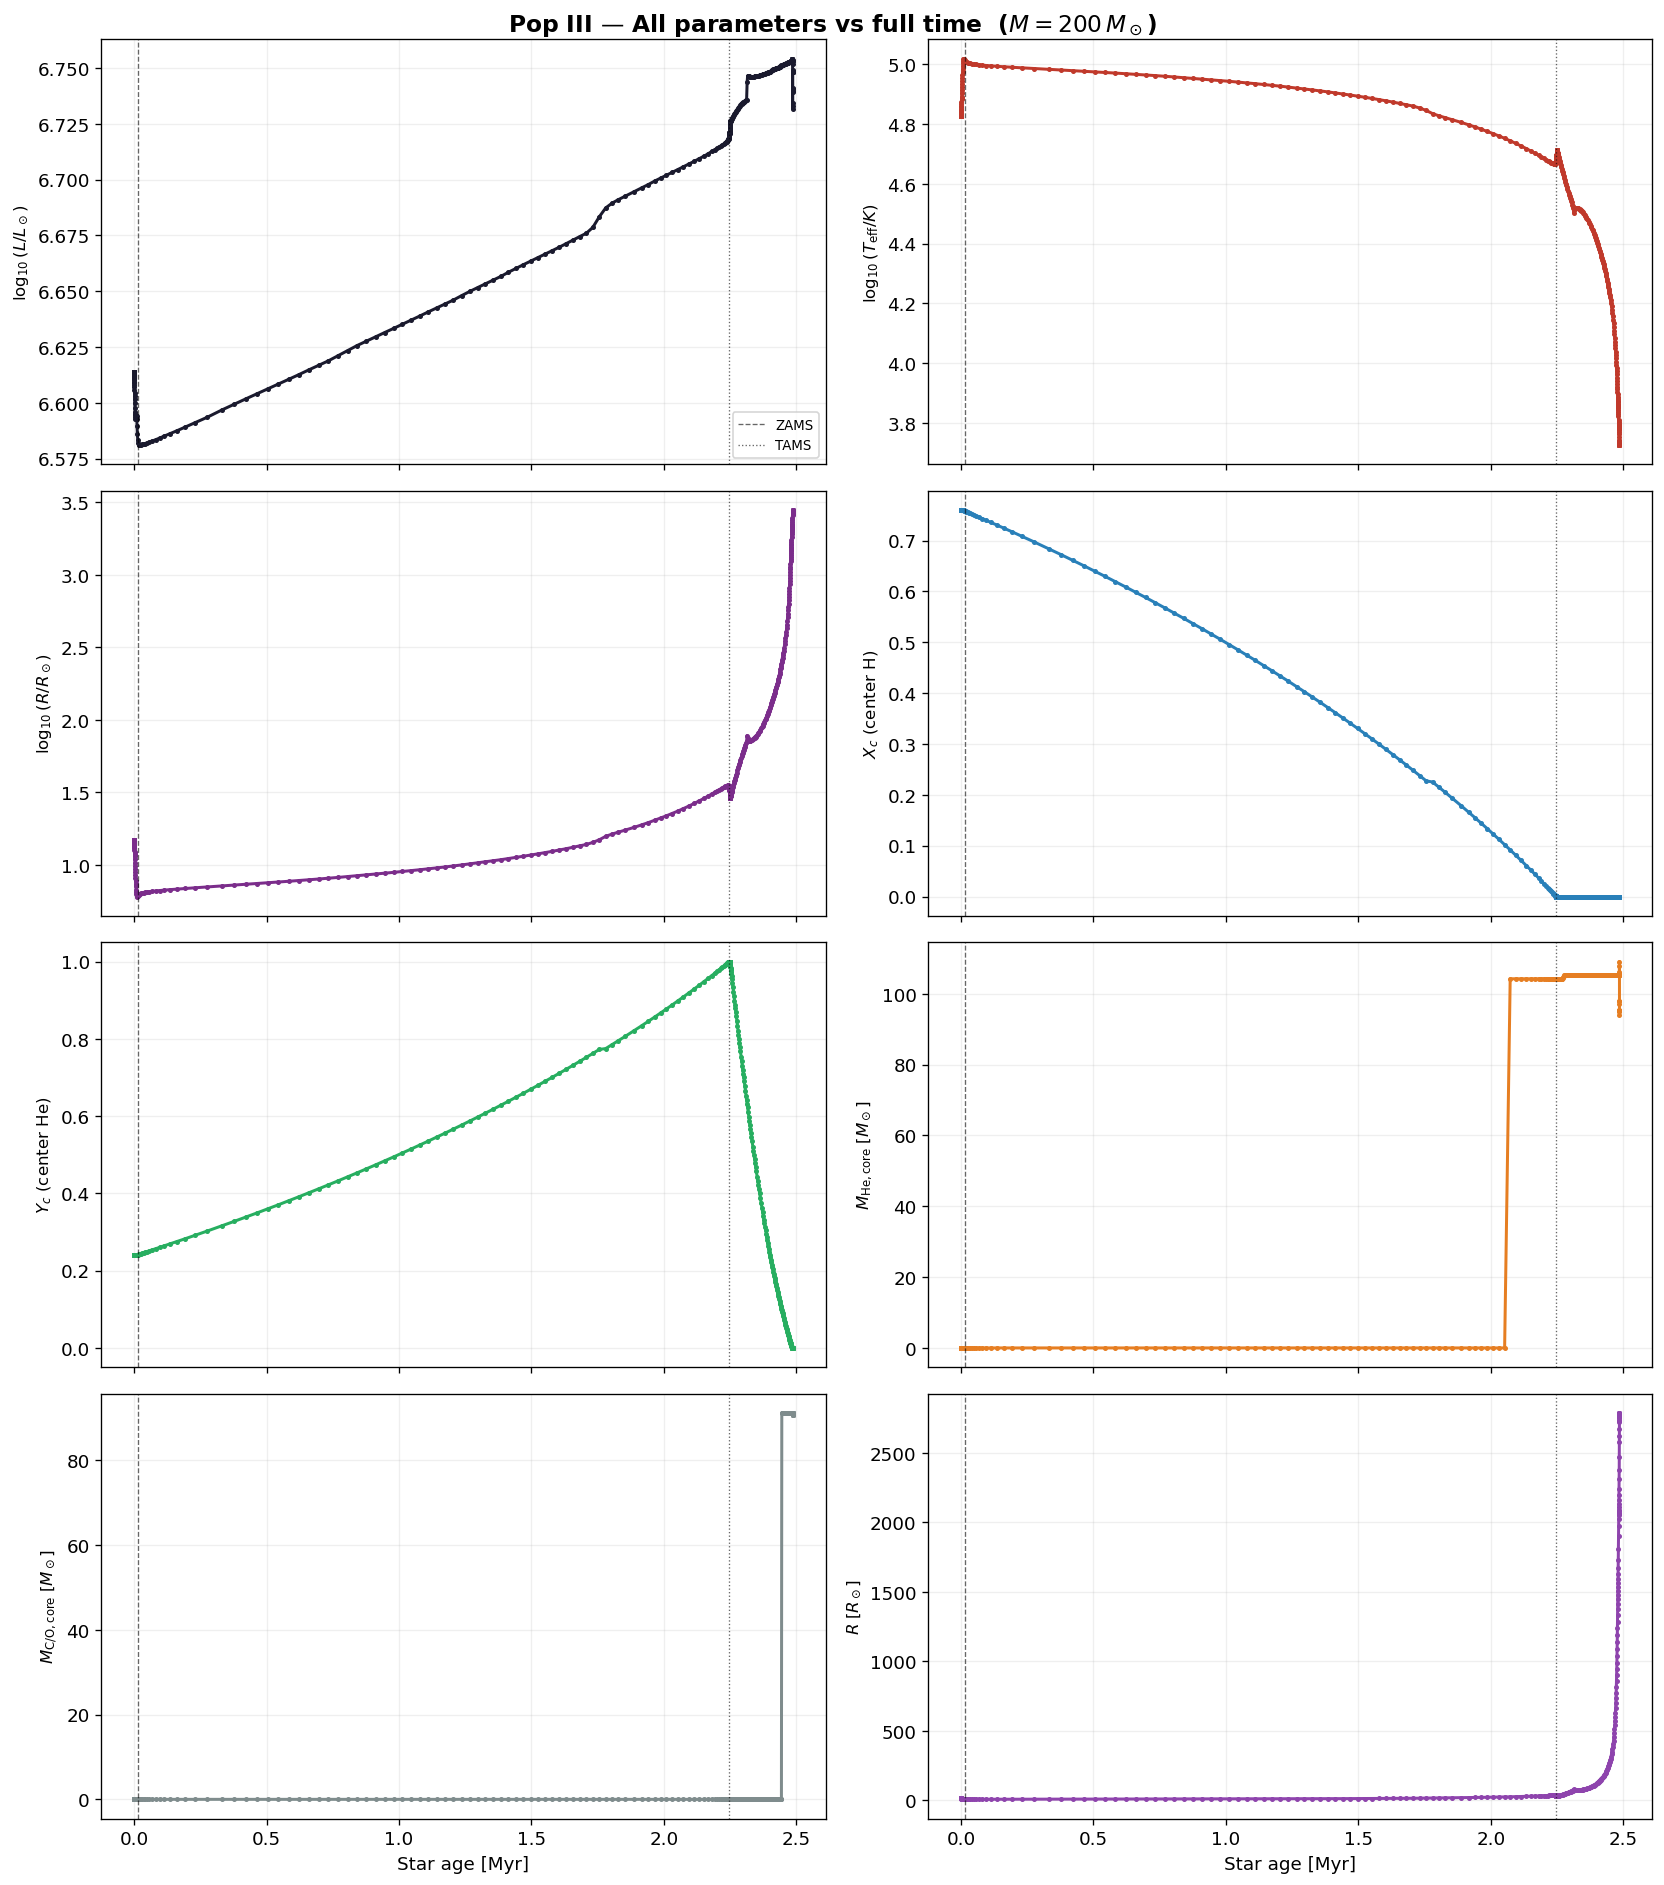

In [49]:
# Uses MASS, df_raw, iz, it, tams_ok, params from the cell above

df_full = df_raw.copy()
df_full['log_R'] = np.log10(df_full['radius'])
t_full = df_full['star_age'].values / 1e6  # Myr

t_zams = df_full['star_age'].iloc[iz] / 1e6
t_tams = df_full['star_age'].iloc[it] / 1e6

fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True)
fig.suptitle(f'Pop III — All parameters vs full time  ($M={MASS}\\,M_\\odot$)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, (col, ylabel, color) in zip(axes, params):
    ax.plot(t_full, df_full[col].values, 'o-', color=color, lw=1.8, ms=2)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(True, alpha=0.2)
    ax.axvline(t_zams, color='k', lw=0.8, ls='--', alpha=0.6, label='ZAMS')
    ax.axvline(t_tams, color='k', lw=0.8, ls=':',  alpha=0.6, label='TAMS')
    if not tams_ok:
        ax.set_facecolor('#fff8e7')

for ax in axes[-2:]:
    ax.set_xlabel('Star age [Myr]', fontsize=11)

axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## 2. Kink diagnostic — step sizes and rates of change

Shows Δt, ΔlogL, ΔlogT, ΔlogR per step, to locate rapid structural changes.

=== M = 200 M☉ — All MS timesteps ===
     tau_H      star_age   log_L  log_Teff   log_R  center_h1  center_he4  he_core_mass
23 0.00000   16955.14026 6.58123   5.00902 0.79523    0.75787     0.24213       0.00000
24 0.00817   35177.35908 6.58151   5.00259 0.80823    0.75369     0.24631       0.00000
25 0.02851   80520.07062 6.58344   4.99705 0.82027    0.74337     0.25663       0.00000
26 0.07911  193347.24661 6.58916   4.98987 0.83749    0.71718     0.28282       0.00000
27 0.18160  421884.46403 6.60179   4.97860 0.86635    0.66128     0.33872       0.00000
28 0.27112  621474.03586 6.61261   4.96842 0.89213    0.60884     0.39116       0.00000
29 0.35383  805900.21240 6.62336   4.95740 0.91953    0.55723     0.44277       0.00000
30 0.43159  979281.31409 6.63332   4.94542 0.94847    0.50576     0.49424       0.00000
31 0.50492 1142796.54766 6.64253   4.93230 0.97932    0.45423     0.54577       0.00000
32 0.57396 1296734.27937 6.65164   4.91723 1.01401    0.40269     0.59731       0.

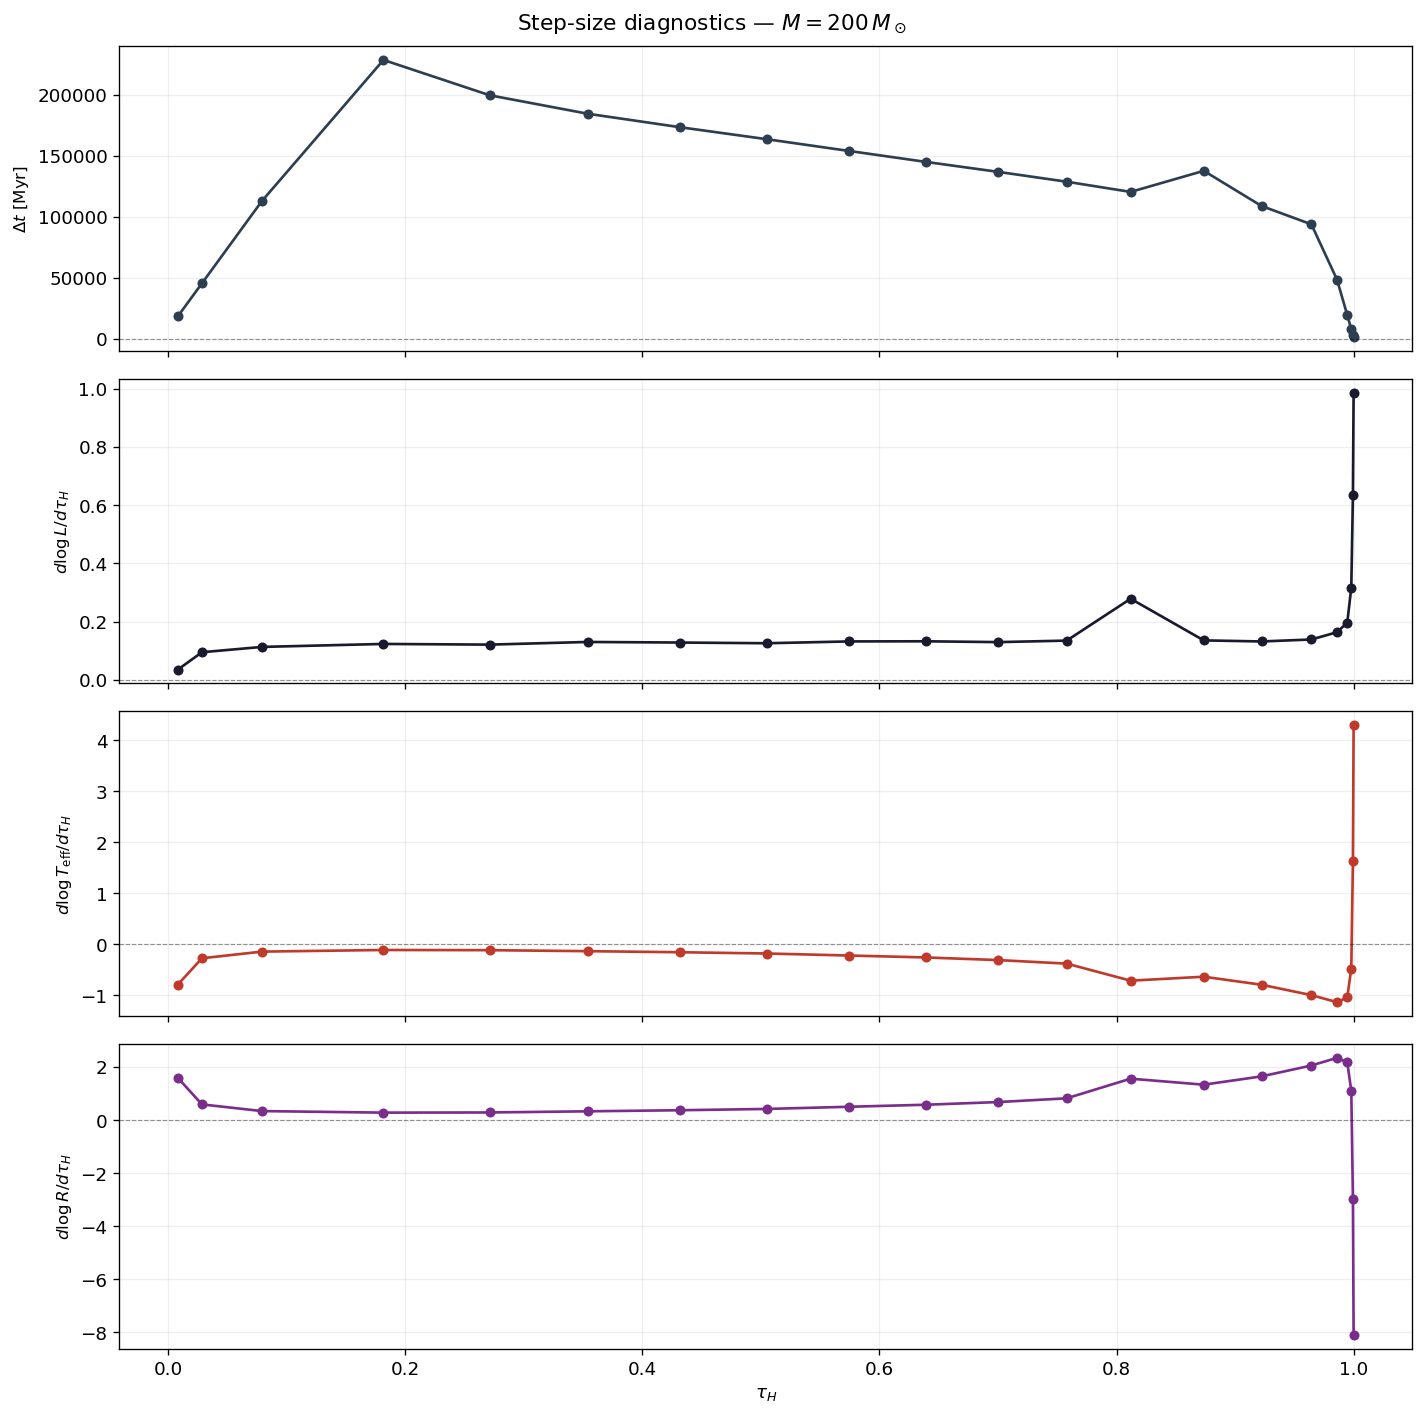

In [6]:
MASS = 200   # ← change this

df_raw = load_profile(MASS)
ms, iz, it, tams_ok = compute_tau(df_raw)

# Print step table
cols_show = ['tau_H', 'star_age', 'log_L', 'log_Teff', 'log_R',
             'center_h1', 'center_he4', 'he_core_mass']
print(f'=== M = {MASS} M☉ — All MS timesteps ===')
print(ms[cols_show].to_string(float_format=lambda x: f'{x:.5f}'))

# Step-size plot
tau = ms['tau_H'].values
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
fig.suptitle(f'Step-size diagnostics — $M={MASS}\\,M_\\odot$', fontsize=13)

pairs = [
    ('dt_Myr',         r'$\Delta t$ [Myr]',              '#2c3e50'),
    ('dlog_L_dtau',    r'$d\log L/d\tau_H$',             '#1a1a2e'),
    ('dlog_Teff_dtau', r'$d\log T_{\rm eff}/d\tau_H$',   '#c0392b'),
    ('dlog_R_dtau',    r'$d\log R/d\tau_H$',             '#7b2d8b'),
]
for ax, (col, ylabel, color) in zip(axes, pairs):
    ax.plot(tau[1:], ms[col].values[1:], 'o-', color=color, lw=1.6, ms=5)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.axhline(0, color='k', lw=0.7, ls='--', alpha=0.4)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel(r'$\tau_H$', fontsize=11)
plt.tight_layout()
plt.show()

---
## 3. Compare multiple masses — L and T_eff

Overlay several masses on the same axes to see whether the kink is systematic.

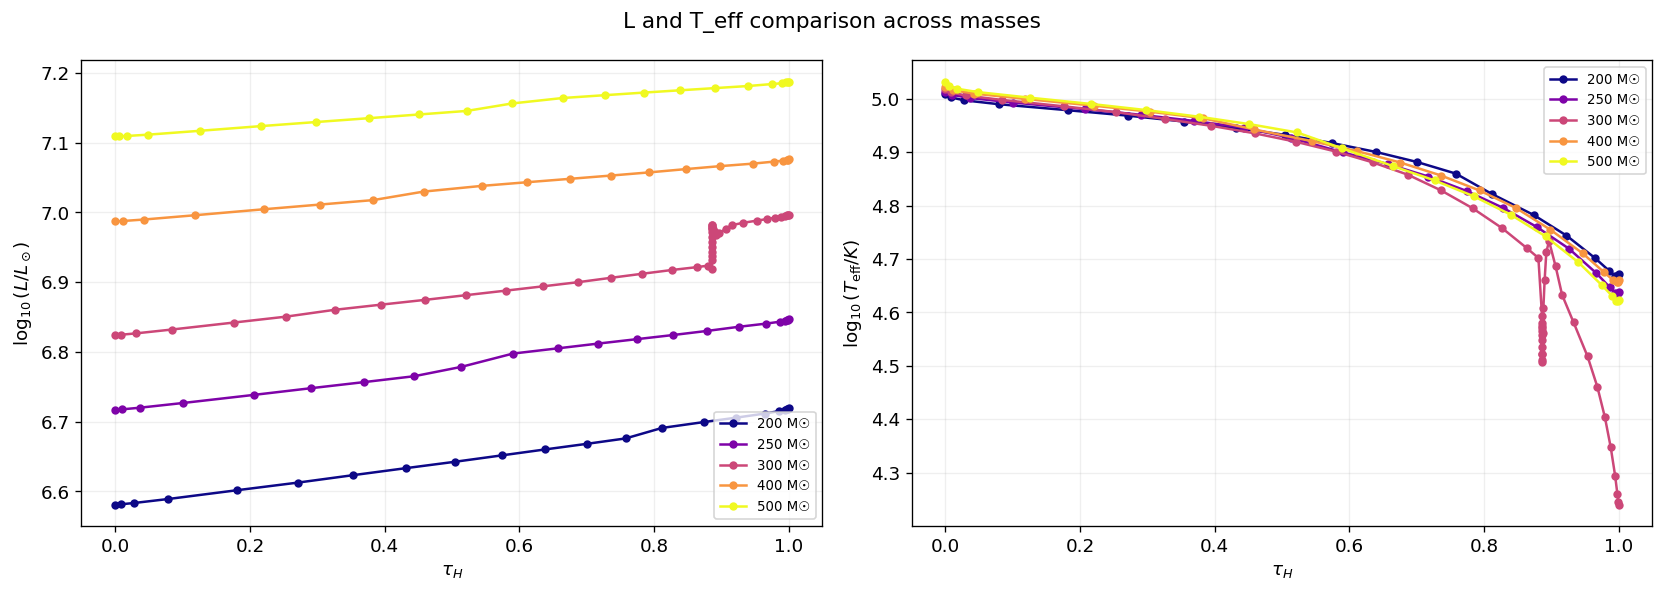

In [7]:
MASSES_TO_COMPARE = [200, 250, 300, 400, 500]   # ← change this

cmap = plt.cm.plasma
colors = [cmap(i / max(len(MASSES_TO_COMPARE)-1, 1)) for i in range(len(MASSES_TO_COMPARE))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('L and T_eff comparison across masses', fontsize=13)

for M, c in zip(MASSES_TO_COMPARE, colors):
    df_raw = load_profile(M)
    if df_raw is None:
        print(f'No profile for M={M}'); continue
    ms, *_ = compute_tau(df_raw)
    tau = ms['tau_H'].values
    axes[0].plot(tau, ms['log_L'].values,    'o-', color=c, lw=1.5, ms=4, label=f'{M} M☉')
    axes[1].plot(tau, ms['log_Teff'].values, 'o-', color=c, lw=1.5, ms=4, label=f'{M} M☉')

axes[0].set_xlabel(r'$\tau_H$'); axes[0].set_ylabel(r'$\log_{10}(L/L_\odot)$')
axes[1].set_xlabel(r'$\tau_H$'); axes[1].set_ylabel(r'$\log_{10}(T_{\rm eff}/K)$')
for ax in axes:
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

---
## 4. HR diagram (log T_eff vs log L)

Classical Hertzsprung-Russell diagram for all selected masses.  
Colour encodes τ_H (blue = ZAMS, yellow = TAMS).

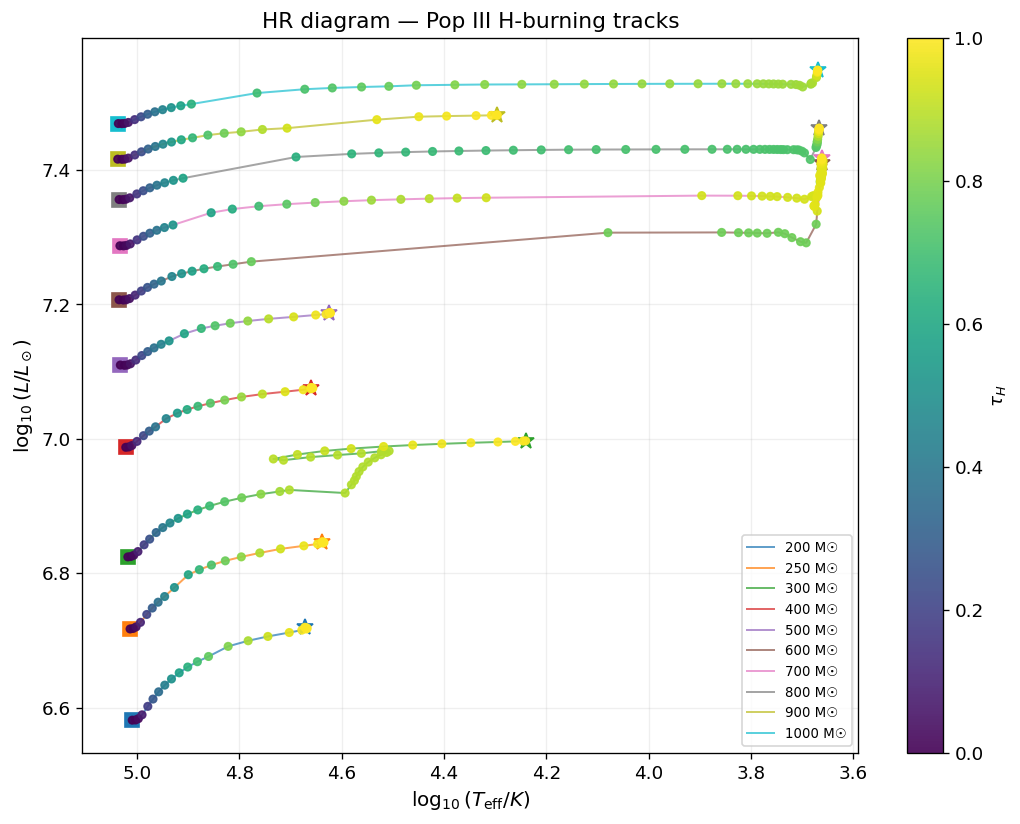

In [9]:
MASSES_HR = [200, 250, 300, 400, 500, 600, 700, 800, 900, 1000]   # ← change

fig, ax = plt.subplots(figsize=(9, 7))
ax.set_xlabel(r'$\log_{10}(T_{\rm eff}/K)$', fontsize=12)
ax.set_ylabel(r'$\log_{10}(L/L_\odot)$', fontsize=12)
ax.set_title('HR diagram — Pop III H-burning tracks', fontsize=13)
ax.invert_xaxis()
ax.grid(True, alpha=0.2)

cmap_hr = plt.cm.viridis
lc_colors = plt.cm.tab10(np.linspace(0, 1, len(MASSES_HR)))

for M, c in zip(MASSES_HR, lc_colors):
    df_raw = load_profile(M)
    if df_raw is None: continue
    ms, *_ = compute_tau(df_raw)
    tau = ms['tau_H'].values
    sc = ax.scatter(ms['log_Teff'].values, ms['log_L'].values,
                    c=tau, cmap='viridis', vmin=0, vmax=1,
                    s=20, zorder=3, alpha=0.9)
    ax.plot(ms['log_Teff'].values, ms['log_L'].values,
            '-', color=c, lw=1.2, alpha=0.7, label=f'{M} M☉')
    # Mark ZAMS and TAMS
    ax.plot(ms['log_Teff'].values[0],  ms['log_L'].values[0],  's', color=c, ms=8)
    ax.plot(ms['log_Teff'].values[-1], ms['log_L'].values[-1], '*', color=c, ms=10)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r'$\tau_H$', fontsize=11)
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

---
## 5. Core composition vs τ_H

Tracks center_h1, center_he4, he_core_mass for a chosen mass.  
Useful for identifying when He core forms and convective core transitions.

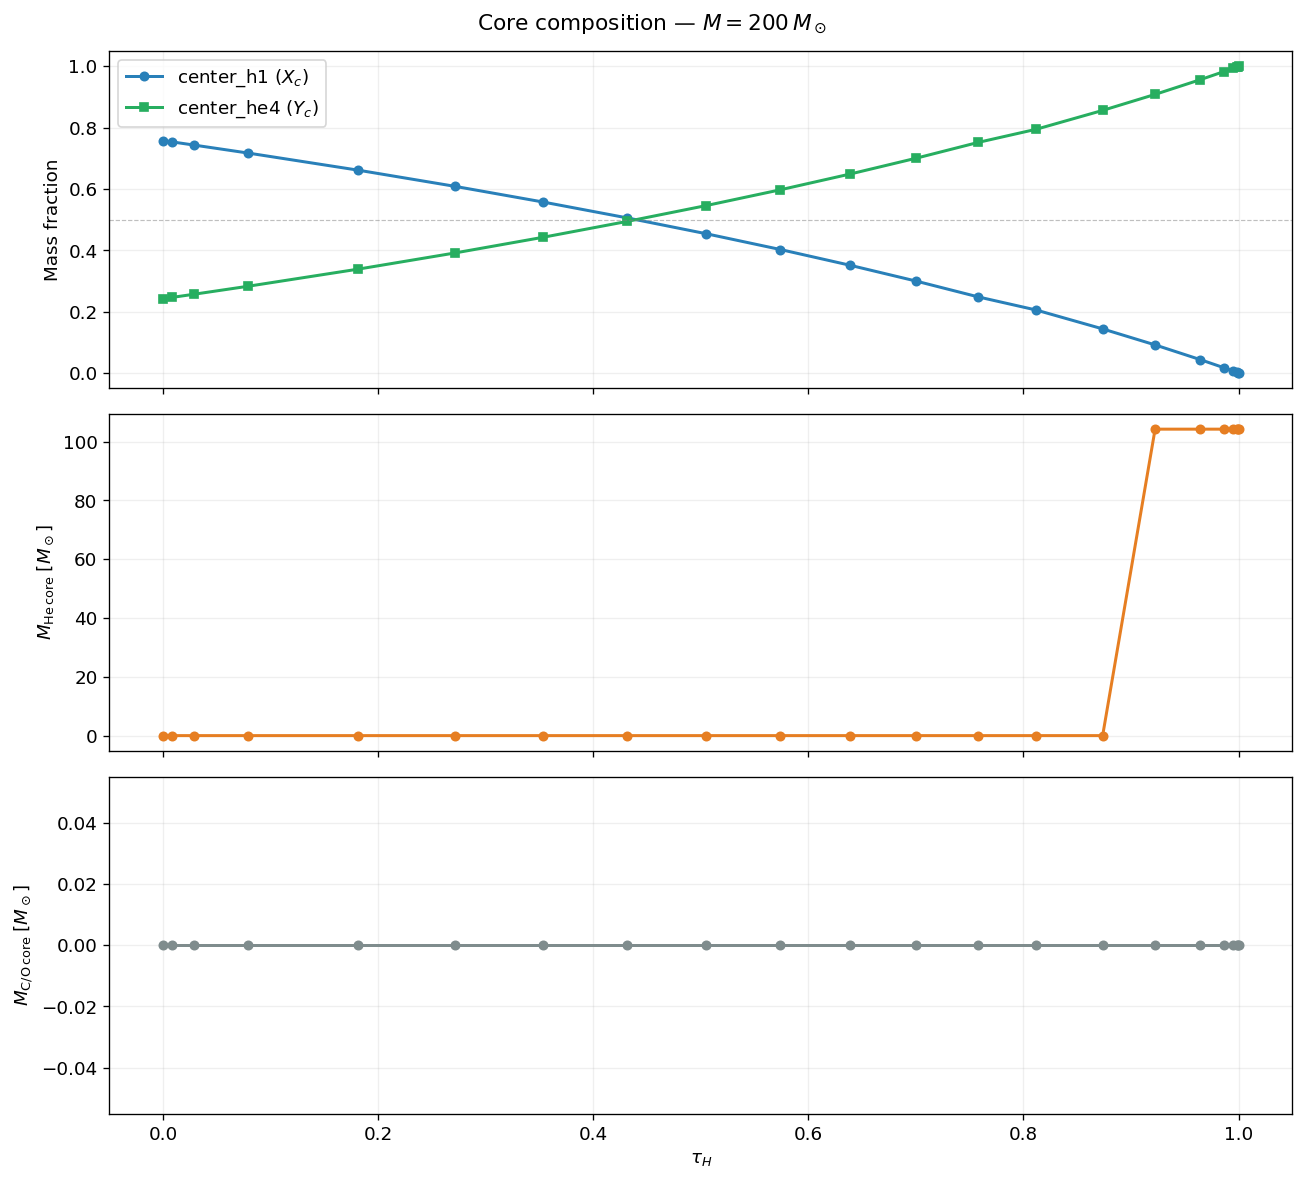


he_core_mass first non-zero at:
  tau_H = 0.9224,  center_h1 = 0.0917,  M_He = 104.24 M☉


In [10]:
MASS = 200   # ← change

df_raw = load_profile(MASS)
ms, iz, it, tams_ok = compute_tau(df_raw)
tau = ms['tau_H'].values

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
fig.suptitle(f'Core composition — $M={MASS}\\,M_\\odot$', fontsize=13)

axes[0].plot(tau, ms['center_h1'].values,  'o-', color='#2980b9', lw=1.8, ms=5, label='center_h1 ($X_c$)')
axes[0].plot(tau, ms['center_he4'].values, 's-', color='#27ae60', lw=1.8, ms=5, label='center_he4 ($Y_c$)')
axes[0].set_ylabel('Mass fraction', fontsize=11)
axes[0].legend(); axes[0].grid(True, alpha=0.2)
axes[0].axhline(0.5, color='grey', lw=0.7, ls='--', alpha=0.5)

axes[1].plot(tau, ms['he_core_mass'].values, 'o-', color='#e67e22', lw=1.8, ms=5)
axes[1].set_ylabel(r'$M_{\rm He\,core}\;[M_\odot]$', fontsize=11)
axes[1].grid(True, alpha=0.2)

axes[2].plot(tau, ms['co_core_mass'].values, 'o-', color='#7f8c8d', lw=1.8, ms=5)
axes[2].set_ylabel(r'$M_{\rm C/O\,core}\;[M_\odot]$', fontsize=11)
axes[2].set_xlabel(r'$\tau_H$', fontsize=11)
axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f'\nhe_core_mass first non-zero at:')
hc = ms[ms['he_core_mass'] > 0]
if len(hc) > 0:
    first = hc.iloc[0]
    print(f'  tau_H = {first["tau_H"]:.4f},  center_h1 = {first["center_h1"]:.4f},  M_He = {first["he_core_mass"]:.2f} M☉')
else:
    print('  Never — he_core_mass = 0 throughout MS')

---
## 6. Radius evolution — looking for rapid expansion

Plots R and log_R vs τ_H. A sudden increase in R causes the kink in T_eff  
(since log T_eff = const + 0.25 × (log L − 2 log R)).

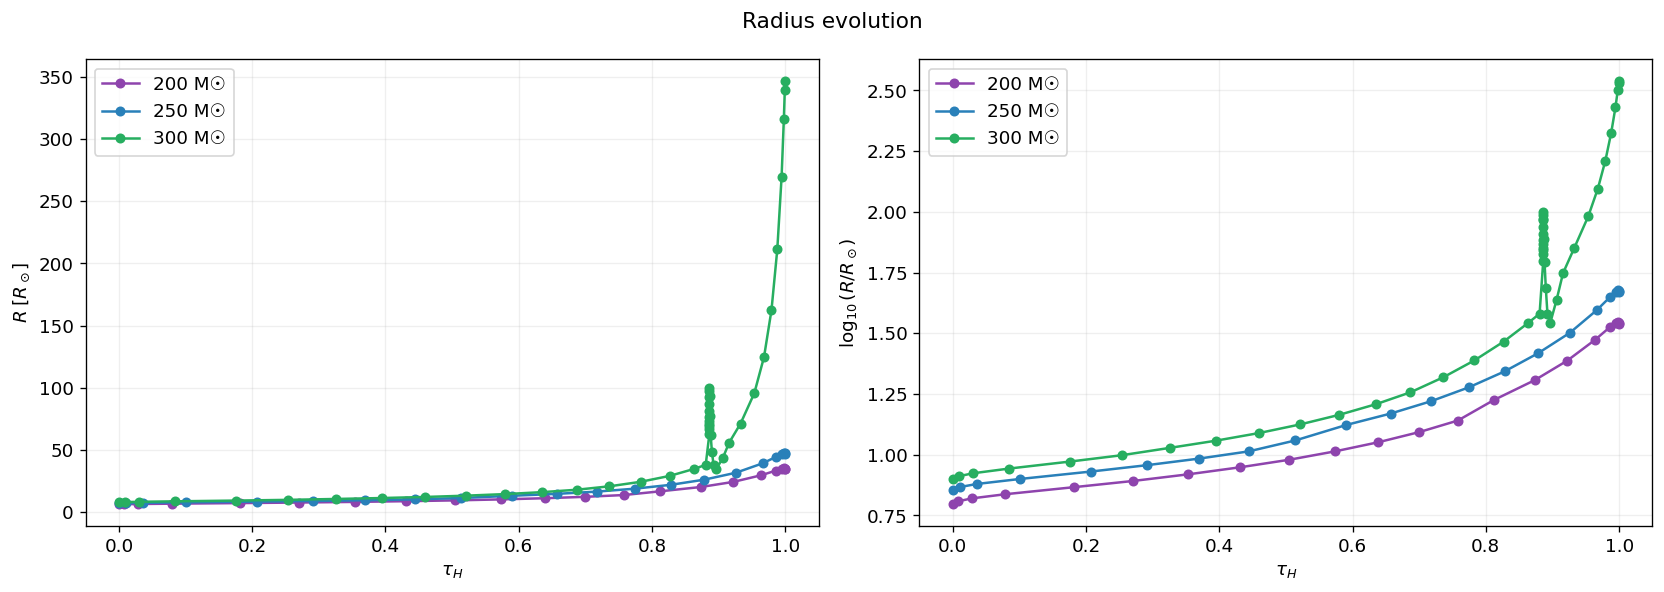

In [11]:
MASSES_R = [200, 250, 300]   # ← change

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Radius evolution', fontsize=13)
colors_r = ['#8e44ad', '#2980b9', '#27ae60', '#e67e22', '#c0392b']

for M, c in zip(MASSES_R, colors_r):
    df_raw = load_profile(M)
    if df_raw is None: continue
    ms, *_ = compute_tau(df_raw)
    tau = ms['tau_H'].values
    axes[0].plot(tau, ms['radius'].values, 'o-', color=c, lw=1.5, ms=5, label=f'{M} M☉')
    axes[1].plot(tau, ms['log_R'].values,  'o-', color=c, lw=1.5, ms=5, label=f'{M} M☉')

axes[0].set_xlabel(r'$\tau_H$'); axes[0].set_ylabel(r'$R\;[R_\odot]$')
axes[1].set_xlabel(r'$\tau_H$'); axes[1].set_ylabel(r'$\log_{10}(R/R_\odot)$')
for ax in axes:
    ax.legend(); ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

---
## 7. All quantities vs star_age (not τ_H)

Useful to check whether the kink is a τ_H normalisation artefact  
or genuinely present in physical time.

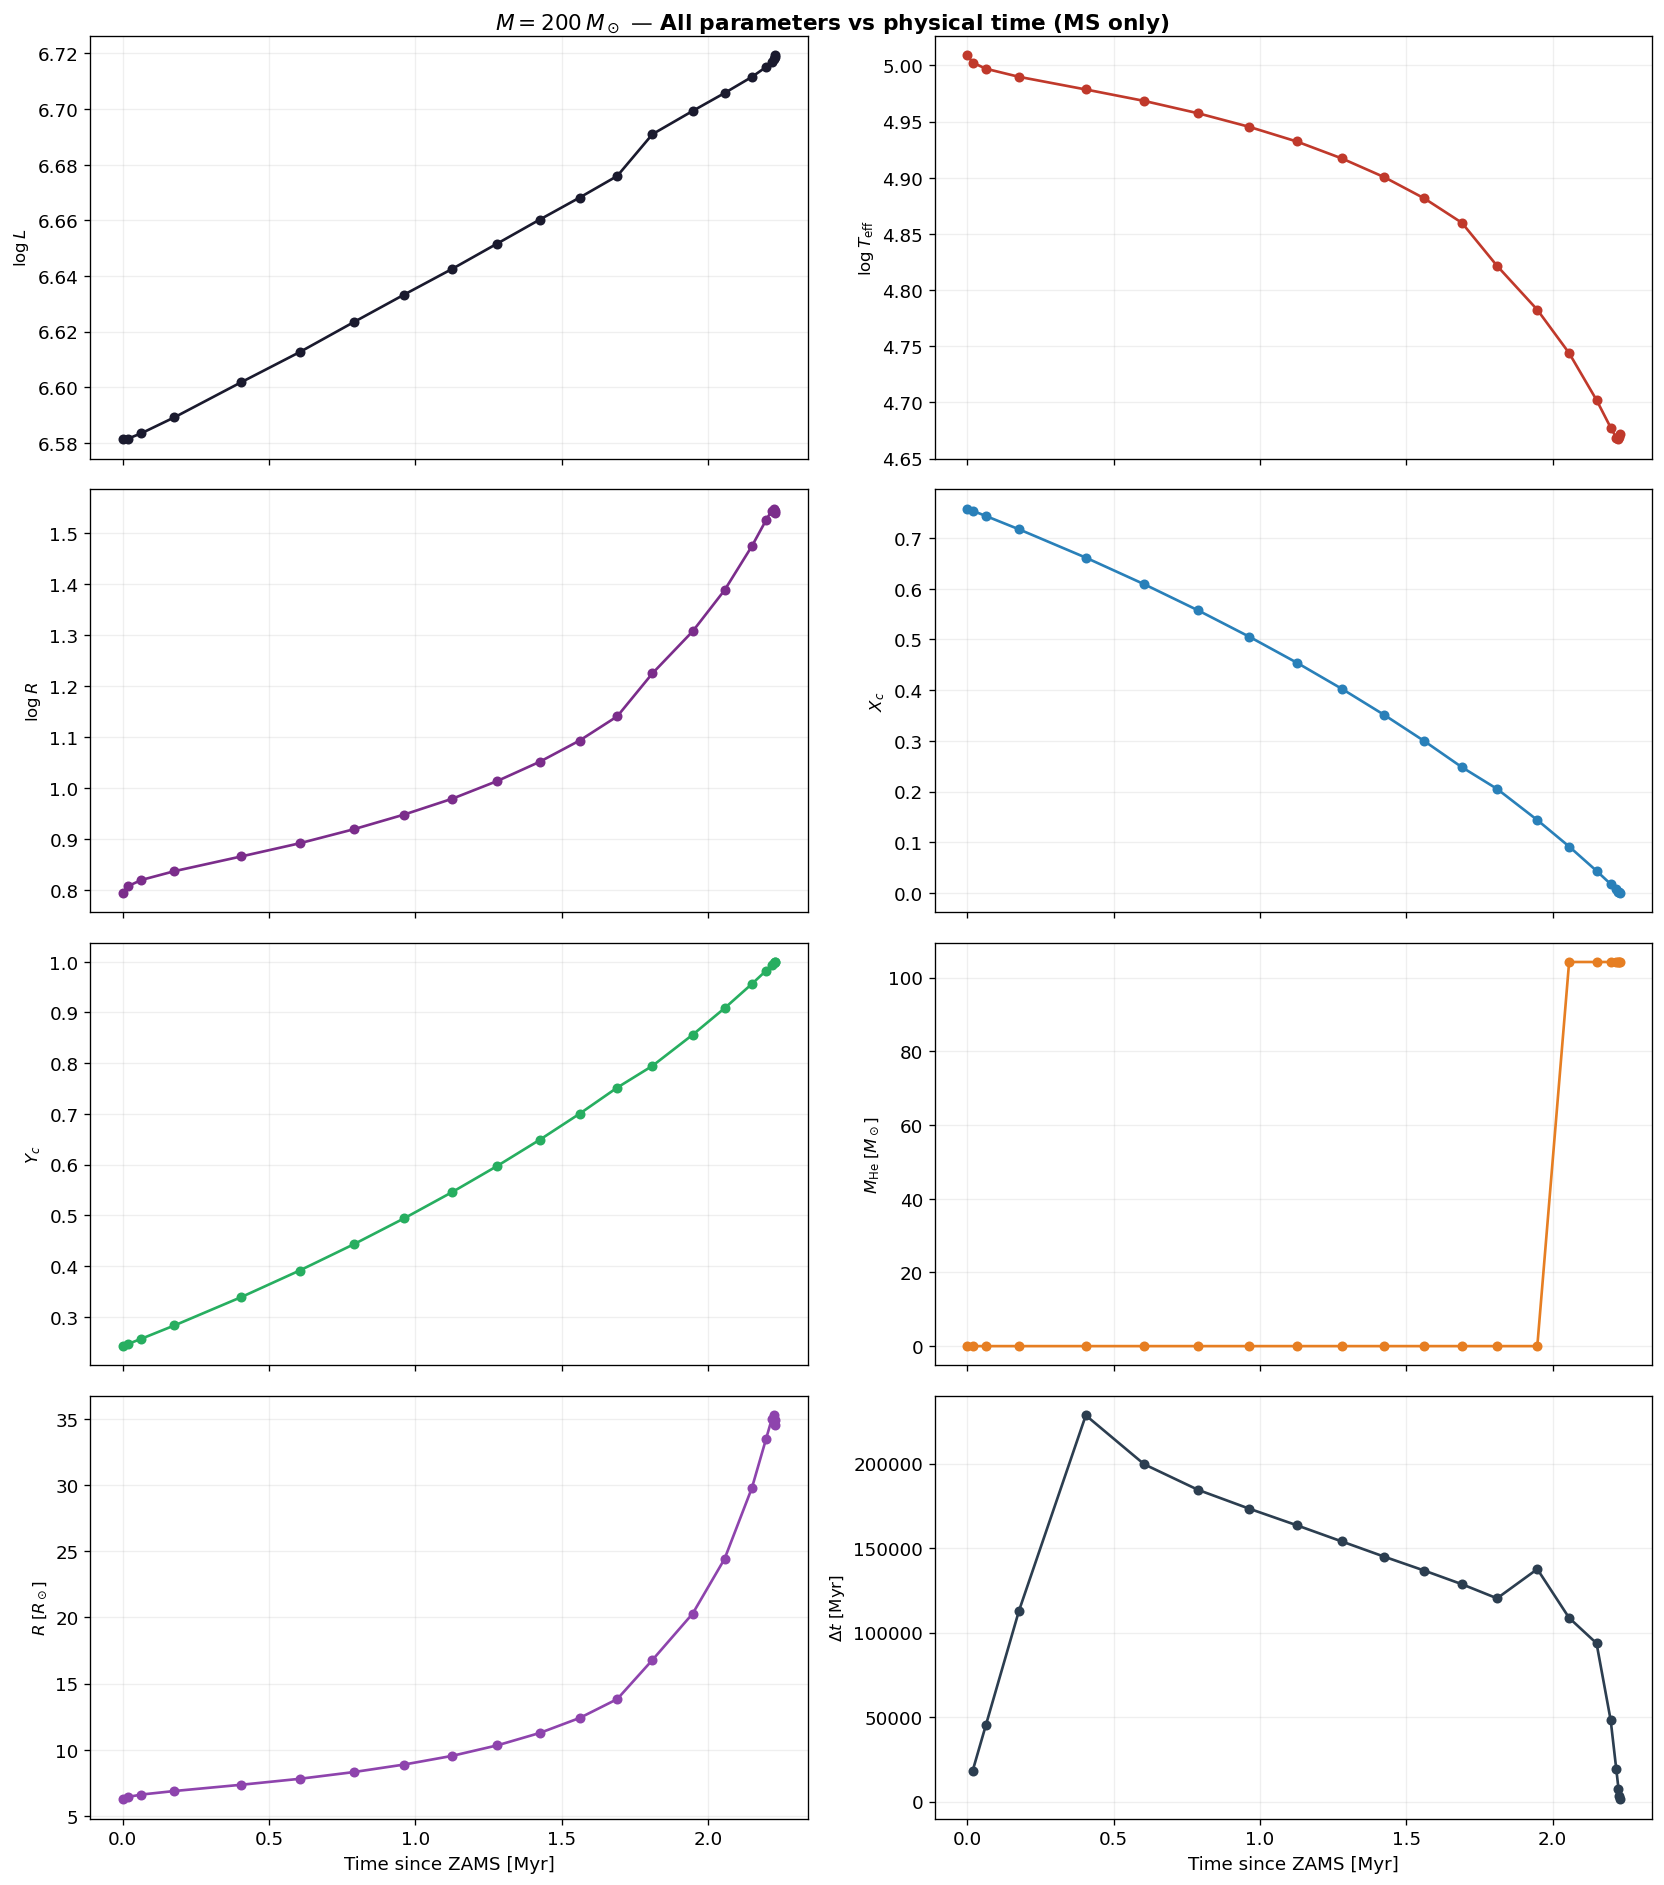

In [12]:
MASS = 200   # ← change

df_raw = load_profile(MASS)
ms, iz, it, tams_ok = compute_tau(df_raw)
t_Myr = (ms['star_age'].values - ms['star_age'].values[0]) / 1e6

params_t = [
    ('log_L',        r'$\log L$',                   '#1a1a2e'),
    ('log_Teff',     r'$\log T_{\rm eff}$',          '#c0392b'),
    ('log_R',        r'$\log R$',                    '#7b2d8b'),
    ('center_h1',    r'$X_c$',                       '#2980b9'),
    ('center_he4',   r'$Y_c$',                       '#27ae60'),
    ('he_core_mass', r'$M_{\rm He}\;[M_\odot]$',     '#e67e22'),
    ('radius',       r'$R\;[R_\odot]$',              '#8e44ad'),
    ('dt_Myr',       r'$\Delta t$ [Myr]',            '#2c3e50'),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True)
fig.suptitle(f'$M={MASS}\\,M_\\odot$ — All parameters vs physical time (MS only)',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for ax, (col, ylabel, color) in zip(axes, params_t):
    vals = ms[col].values if col != 'dt_Myr' else ms[col].values
    x    = t_Myr
    if col == 'dt_Myr':
        ax.plot(x[1:], vals[1:], 'o-', color=color, lw=1.6, ms=5)
    else:
        ax.plot(x, vals, 'o-', color=color, lw=1.6, ms=5)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(True, alpha=0.2)

for ax in axes[-2:]:
    ax.set_xlabel('Time since ZAMS [Myr]', fontsize=11)

plt.tight_layout()
plt.show()

---
## 8. Rate-acceleration map — all high masses

For each mass, shows the step-by-step ΔlogL and ΔlogT per Δτ_H step.  
A sudden jump in these rates marks the kink τ position.

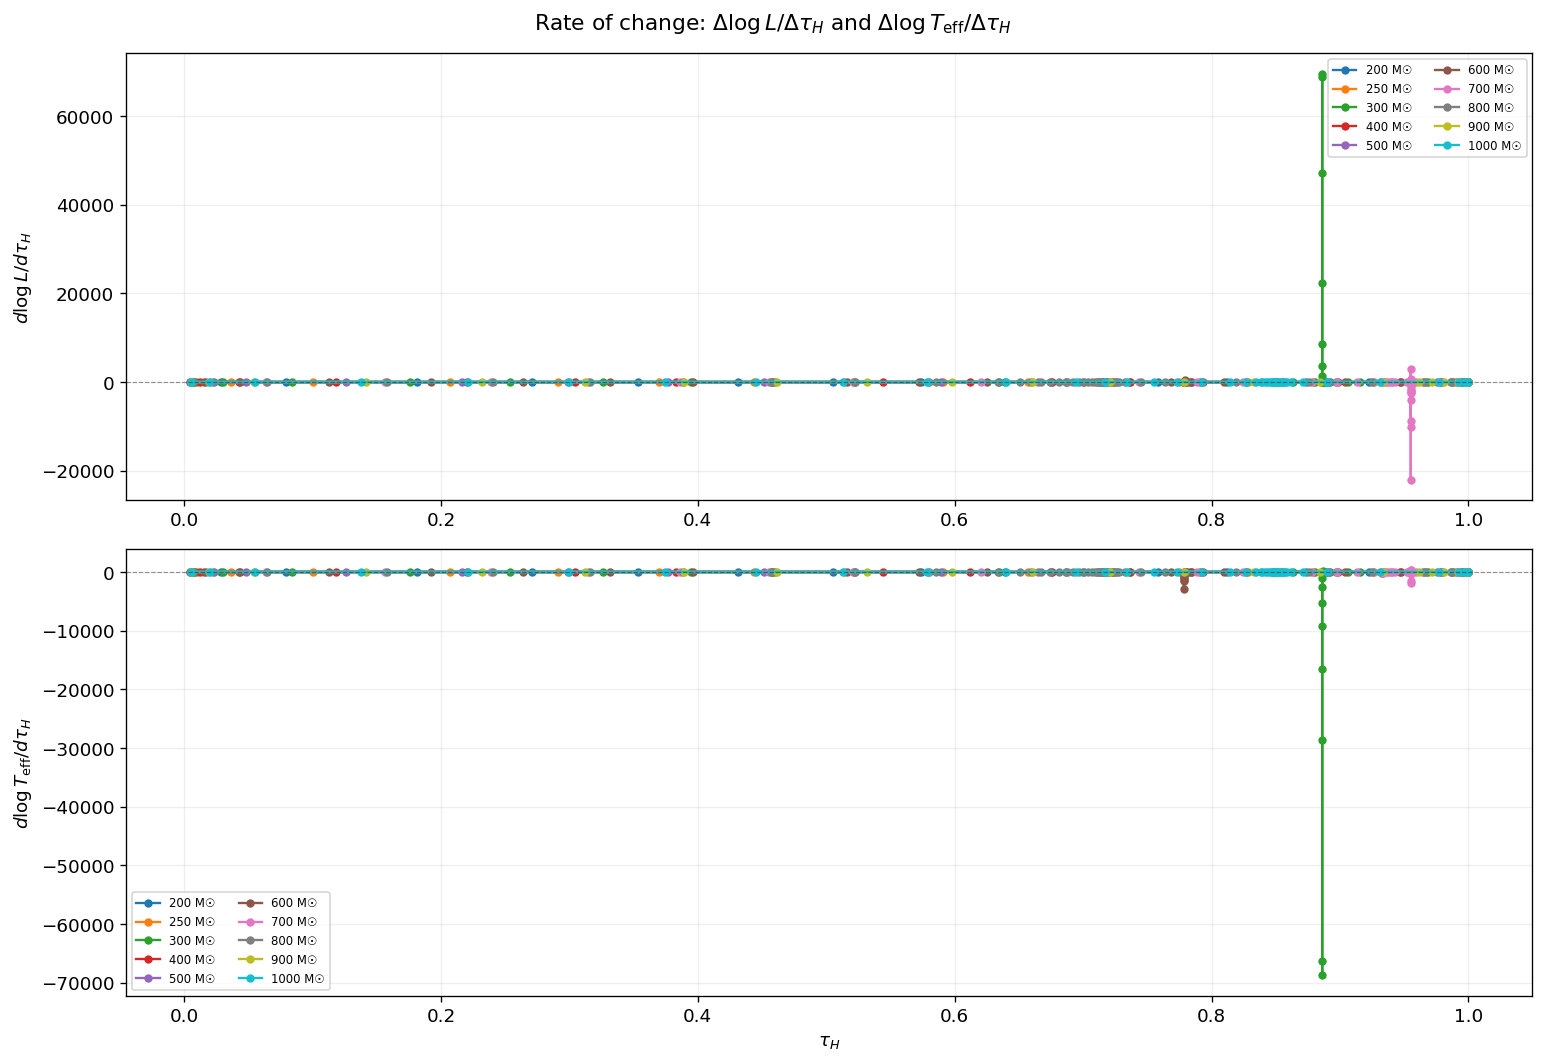

In [13]:
MASSES_RATE = [200, 250, 300, 400, 500, 600, 700, 800, 900, 1000]

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=False)
fig.suptitle(r'Rate of change: $\Delta\log L / \Delta\tau_H$ and $\Delta\log T_{\rm eff} / \Delta\tau_H$',
             fontsize=13)

cmap2 = plt.cm.tab10

for i, M in enumerate(MASSES_RATE):
    df_raw = load_profile(M)
    if df_raw is None: continue
    ms, *_ = compute_tau(df_raw)
    tau = ms['tau_H'].values
    c = cmap2(i / 10)
    axes[0].plot(tau[1:], ms['dlog_L_dtau'].values[1:],
                 'o-', color=c, lw=1.4, ms=4, label=f'{M} M☉')
    axes[1].plot(tau[1:], ms['dlog_Teff_dtau'].values[1:],
                 'o-', color=c, lw=1.4, ms=4, label=f'{M} M☉')

axes[0].set_ylabel(r'$d\log L / d\tau_H$', fontsize=11)
axes[1].set_ylabel(r'$d\log T_{\rm eff} / d\tau_H$', fontsize=11)
axes[1].set_xlabel(r'$\tau_H$', fontsize=11)

for ax in axes:
    ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.2)
    ax.axhline(0, color='k', lw=0.7, ls='--', alpha=0.4)

plt.tight_layout()
plt.show()

---
## 9. Raw data table — any mass

Print the full MS data table for inspection.

In [14]:
MASS = 200   # ← change

df_raw = load_profile(MASS)
ms, iz, it, tams_ok = compute_tau(df_raw)

display_cols = ['tau_H', 'star_age', 'log_L', 'log_Teff', 'log_R',
                'center_h1', 'center_he4', 'he_core_mass', 'co_core_mass',
                'radius', 'dt_Myr']

pd.set_option('display.float_format', '{:.5f}'.format)
pd.set_option('display.max_rows', 100)
display(ms[display_cols].reset_index(drop=True))

,tau_H,star_age,log_L,log_Teff,log_R,center_h1,center_he4,he_core_mass,co_core_mass,radius,dt_Myr
0,0.00000,16955.14026,6.58123,5.00902,0.79523,0.75787,0.24213,0.00000,0.00000,6.24072,7323.10106
1,0.00817,35177.35908,6.58151,5.00259,0.80823,0.75369,0.24631,0.00000,0.00000,6.43036,18222.21882
2,0.02851,80520.07062,6.58344,4.99705,0.82027,0.74337,0.25663,0.00000,0.00000,6.61097,45342.71154
3,0.07911,193347.24661,6.58916,4.98987,0.83749,0.71718,0.28282,0.00000,0.00000,6.87847,112827.17598
4,0.18160,421884.46403,6.60179,4.97860,0.86635,0.66128,0.33872,0.00000,0.00000,7.35112,228537.21743
5,0.27112,621474.03586,6.61261,4.96842,0.89213,0.60884,0.39116,0.00000,0.00000,7.80057,199589.57183
6,0.35383,805900.21240,6.62336,4.95740,0.91953,0.55723,0.44277,0.00000,0.00000,8.30860,184426.17654
7,0.43159,979281.31409,6.63332,4.94542,0.94847,0.50576,0.49424,0.00000,0.00000,8.88120,173381.10169
8,0.50492,1142796.54766,6.64253,4.93230,0.97932,0.45423,0.54577,0.00000,0.00000,9.53497,163515.23358
9,0.57396,1296734.27937,6.65164,4.91723,1.01401,0.40269,0.59731,0.00000,0.00000,10.32787,153937.73171


In [58]:
import txt_to_csv as ttc
ttc.txt_to_csv("/Users/igeondong/KCL/Project/Profiles/profile_txt/profile_200.0_2.txt")


Saved: /Users/igeondong/KCL/Project/Profiles/profile_csv/profile_200.0_2.csv
